In [9]:
# script mainly based on this tutorial: 
# https://htmlpreview.github.io/?https://github.com/jinworks/CellChat/blob/master/tutorial/CellChat-vignette.html#part-ii-inference-of-cell-cell-communication-network

# Load libraries and scripts ---------------------------------------------------
library(dplyr)
library(Seurat)
library(schard)
#library(SpatialCellChat)
library(CellChat)
library(patchwork)
options(stringsAsFactors = FALSE)


# Set paths --------------------------------------------------------------------
MAIN_DIR <- "/mnt/data/project0062/proseg_data"
setwd(MAIN_DIR)

# cellchat functions 
source("code/8_lr_analysis/cellchat-functions.R")

# Setting seed
SEED_VALUE <- 42
set.seed(SEED_VALUE)

# Set up parallel processing ---------------------------------------------------
future::plan("multisession", workers = 4) 
options(future.globals.maxSize = 4 * 1024^3)
# helps speed up LR identification

# Niche object path ------------------------------------------------------------

COND <- "CF"
OBJ_NAME <- paste0(COND,".cellchat.rds")

IN_OBJ_PATH <- file.path(
  MAIN_DIR, "results", "comb-full", "lr-manual-niches", "airway_epithelium", OBJ_NAME
)

OUT_DIR <- file.path(
  MAIN_DIR, "results", "comb-full", "lr-manual-niches", "airway_epithelium", COND
)


# create out dir 
if (!dir.exists(OUT_DIR)) {
    dir.create(OUT_DIR, recursive = TRUE)
}


In [11]:
# load the niche object --------------------------------------------------------
cellchat <- readRDS(IN_OBJ_PATH)

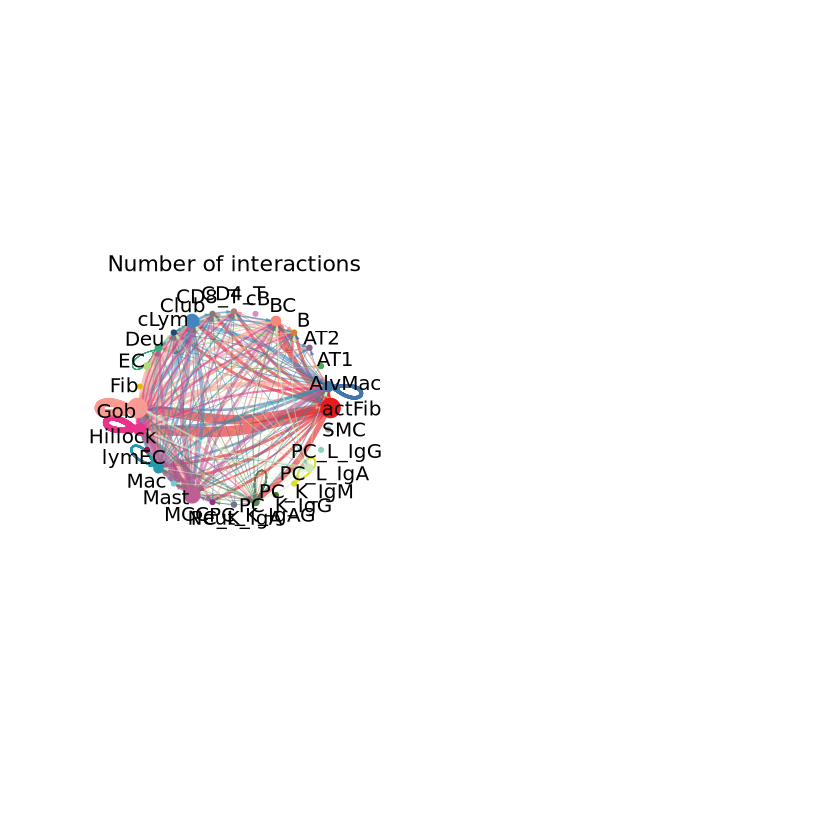

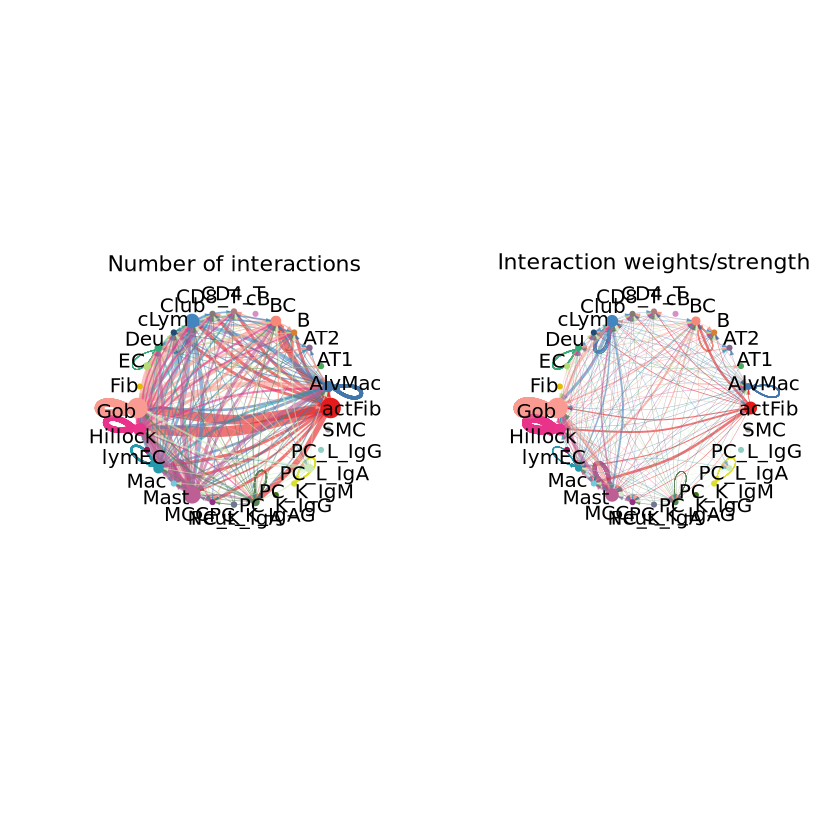

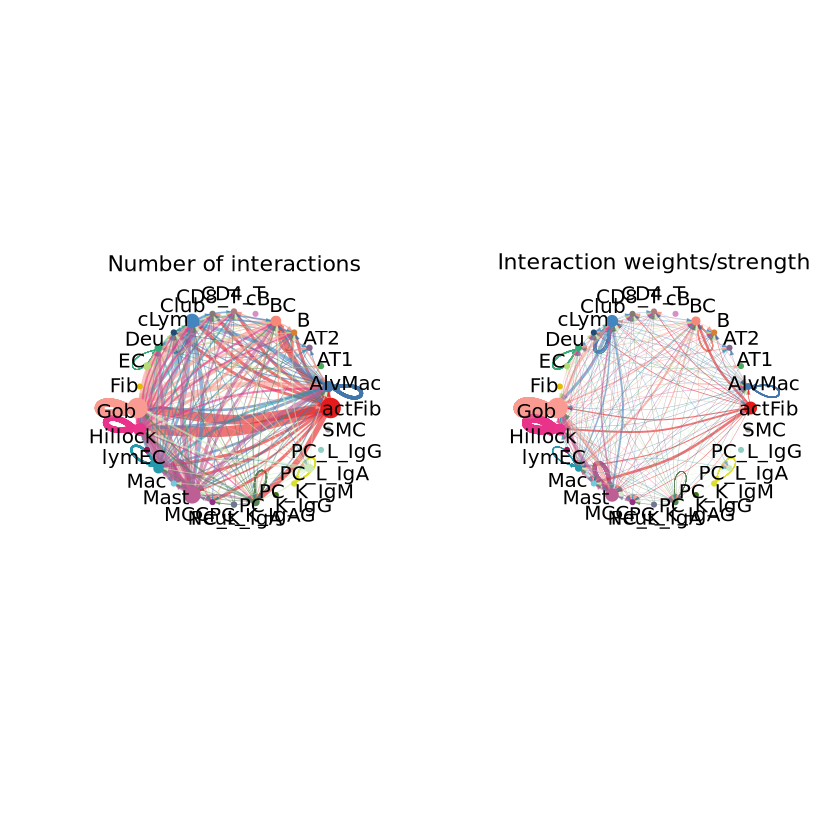

In [15]:


# interactions 

ptm = Sys.time()

groupSize <- as.numeric(table(cellchat@idents))
par(mfrow = c(1,2), xpd=TRUE)
netVisual_circle(cellchat@net$count, vertex.weight = rowSums(cellchat@net$count), weight.scale = T, label.edge= F, title.name = "Number of interactions")
netVisual_circle(cellchat@net$weight, vertex.weight = rowSums(cellchat@net$weight), weight.scale = T, label.edge= F, title.name = "Interaction weights/strength")



Do heatmap based on a single object 


Do heatmap based on a single object 




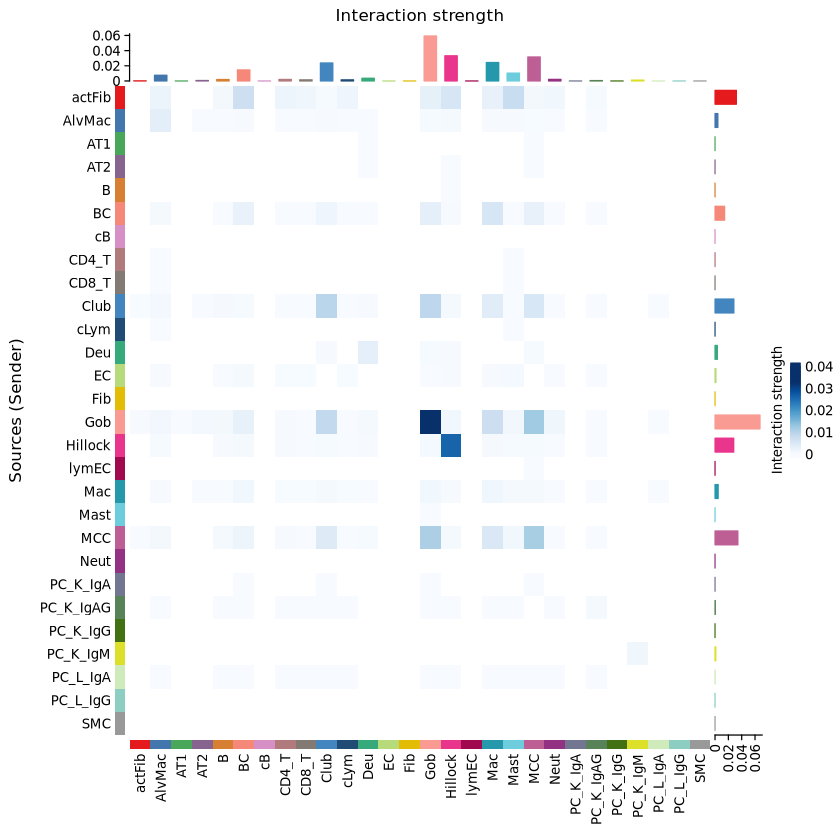

In [14]:

# other plot 
netVisual_heatmap(cellchat, measure = "count", color.heatmap = "Blues")
netVisual_heatmap(cellchat, measure = "weight", color.heatmap = "Blues")

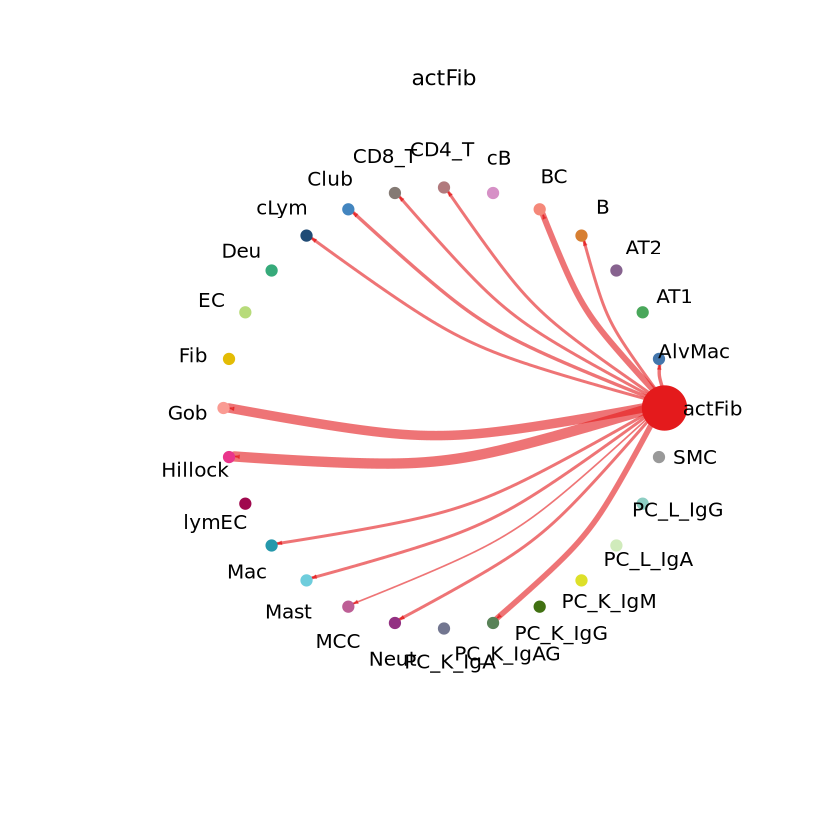

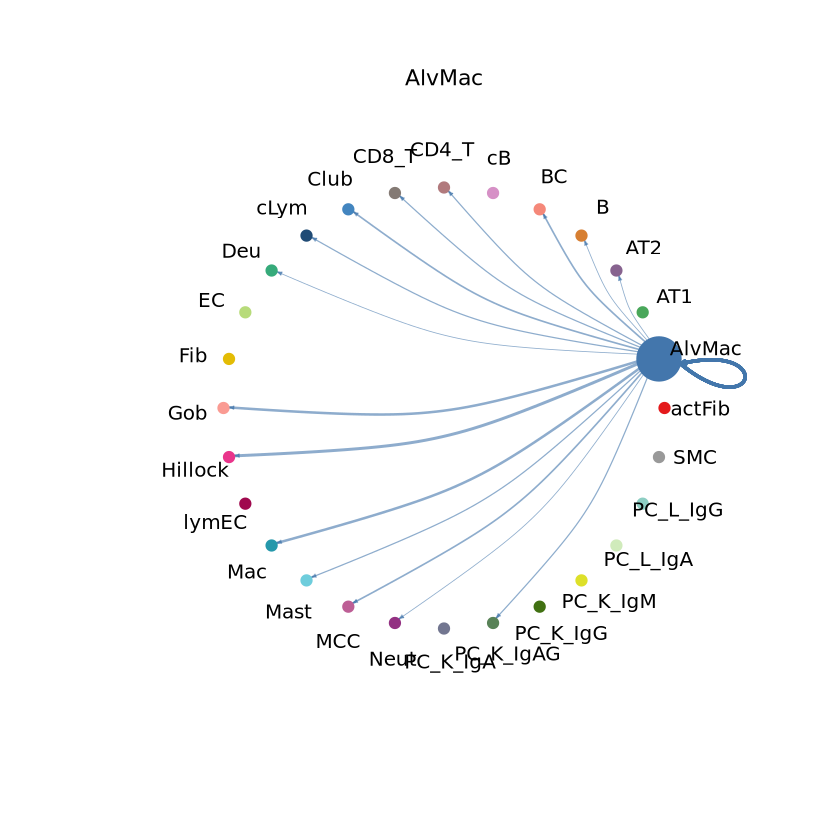

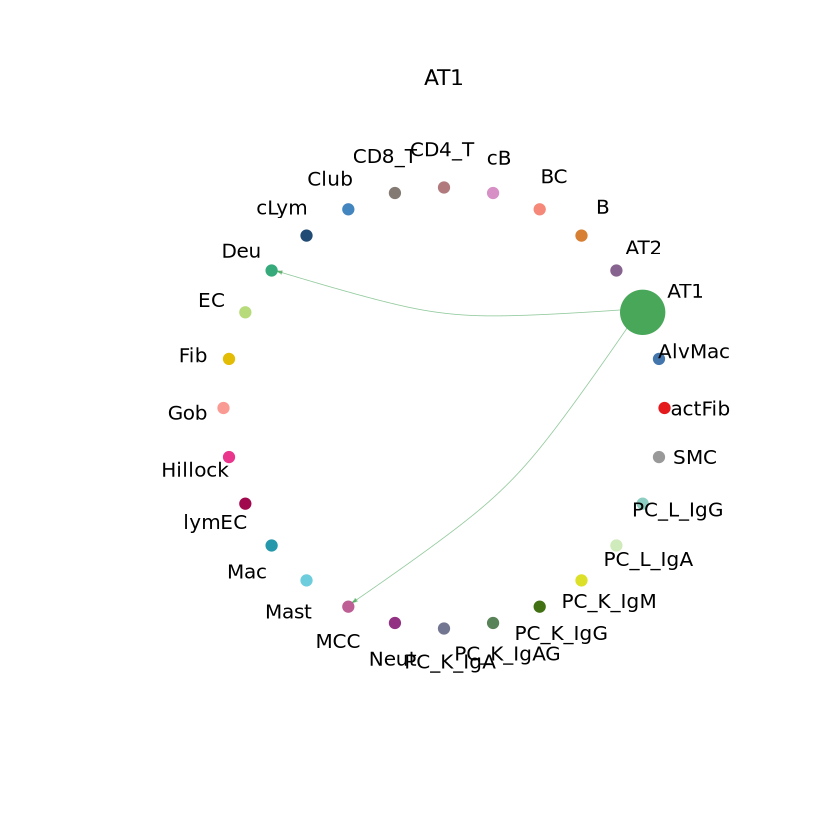

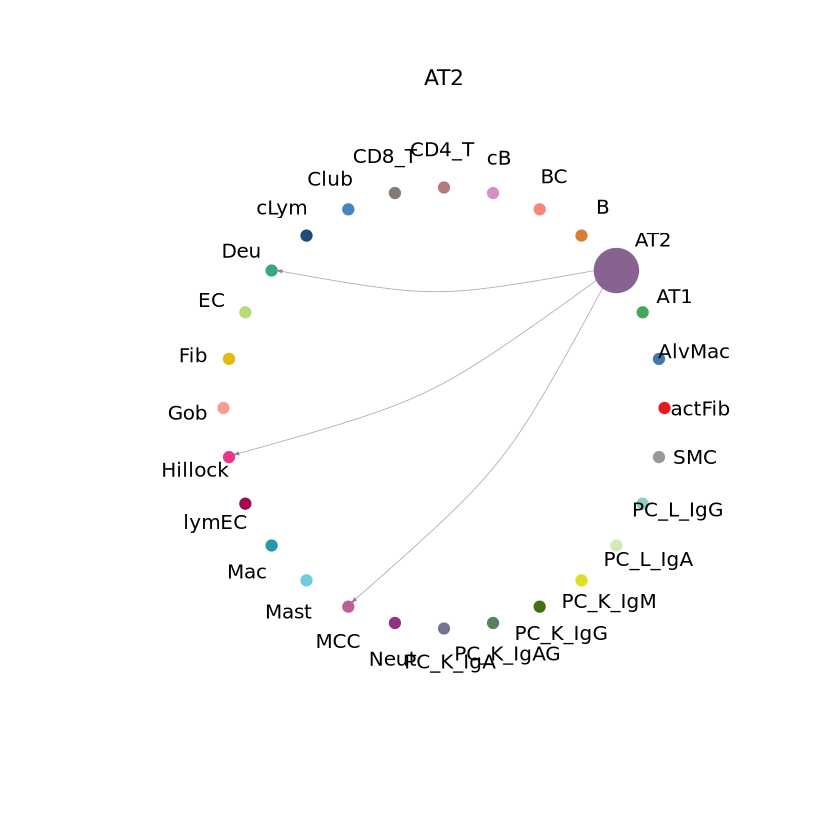

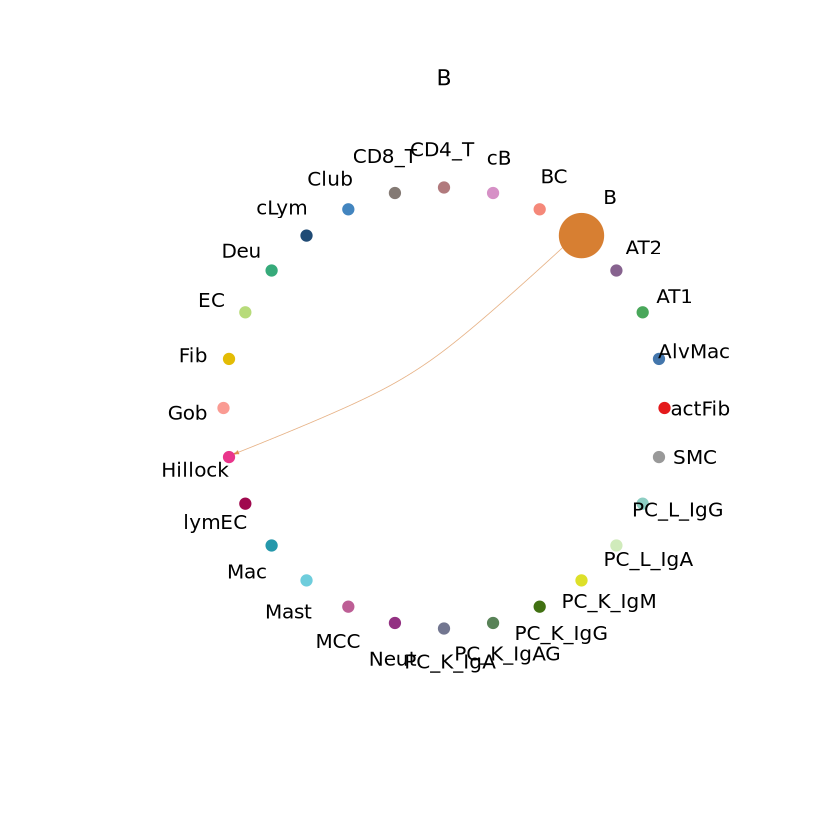

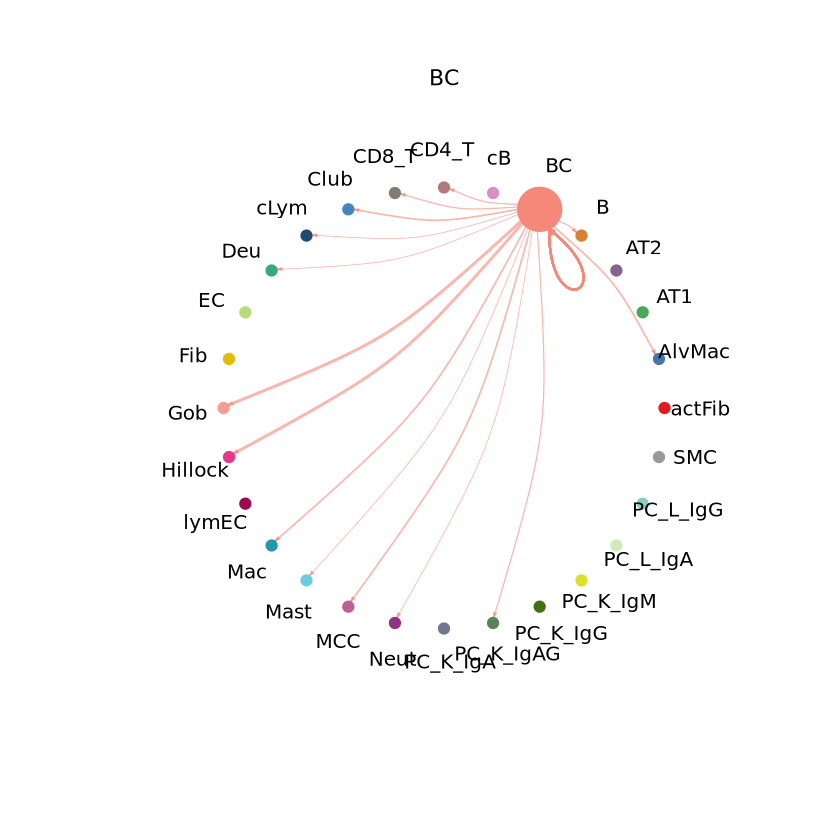

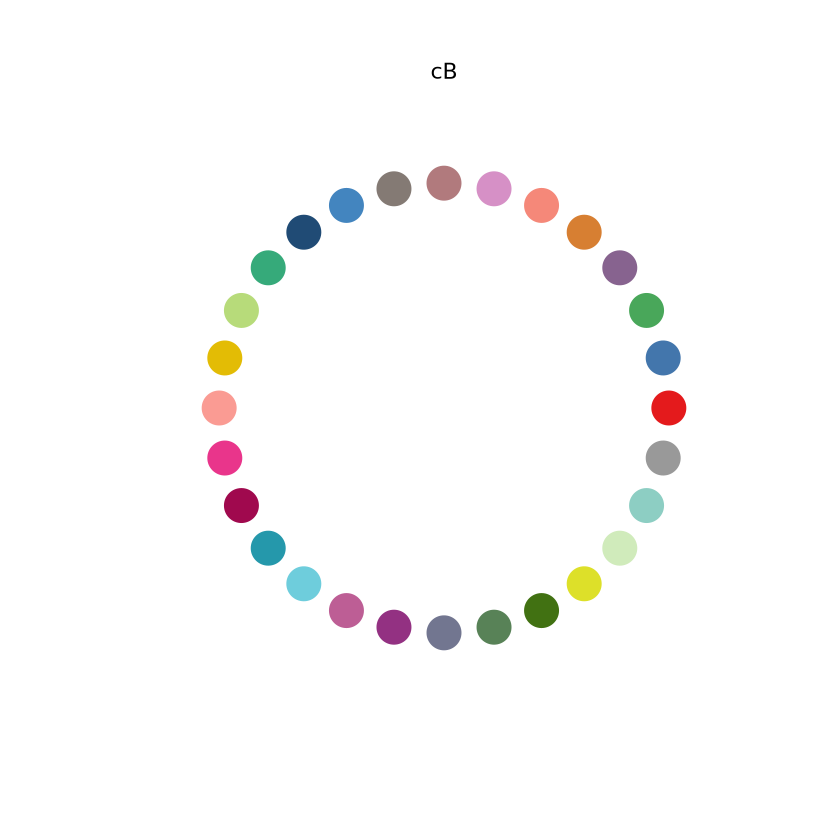

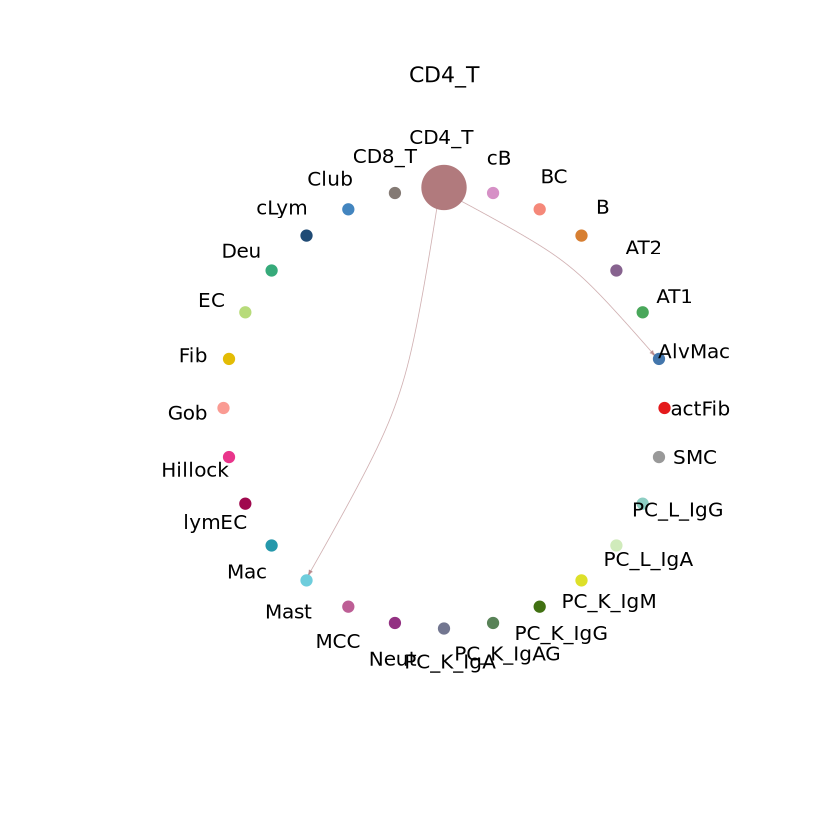

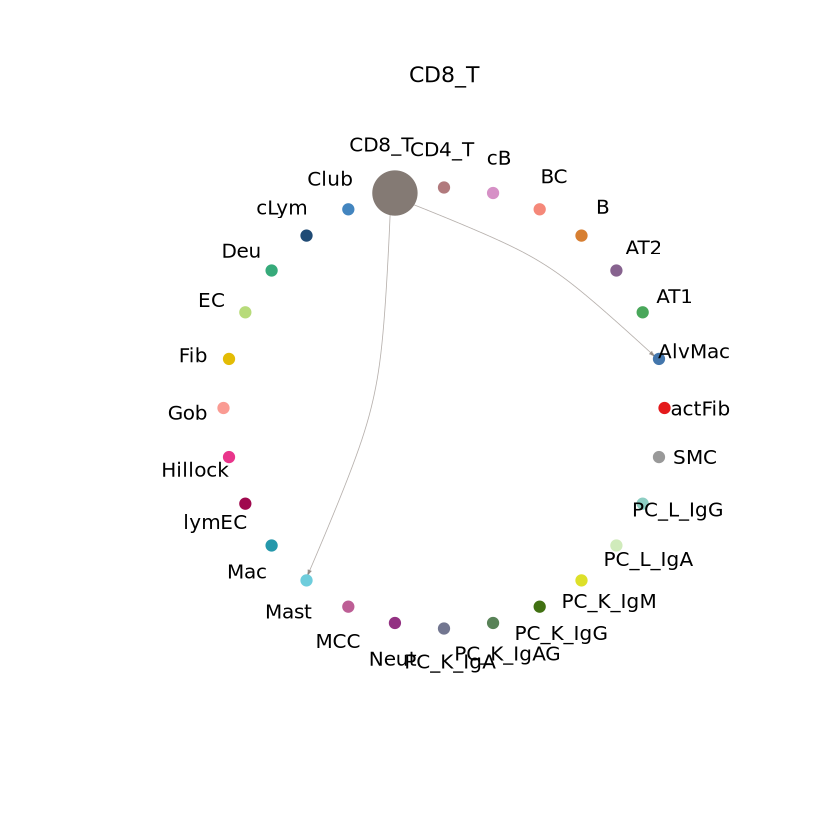

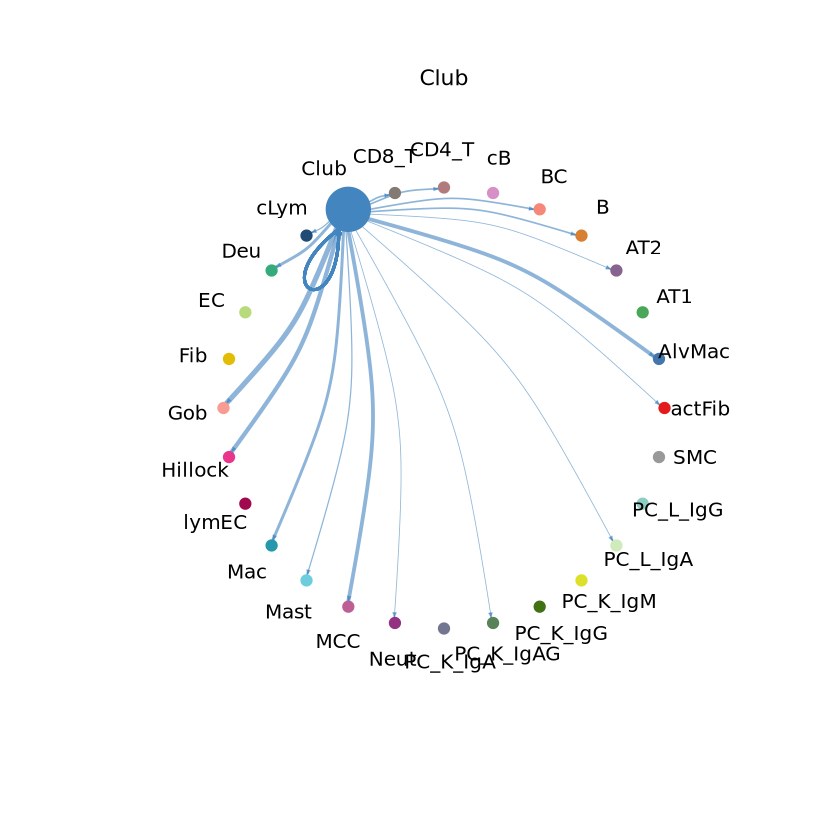

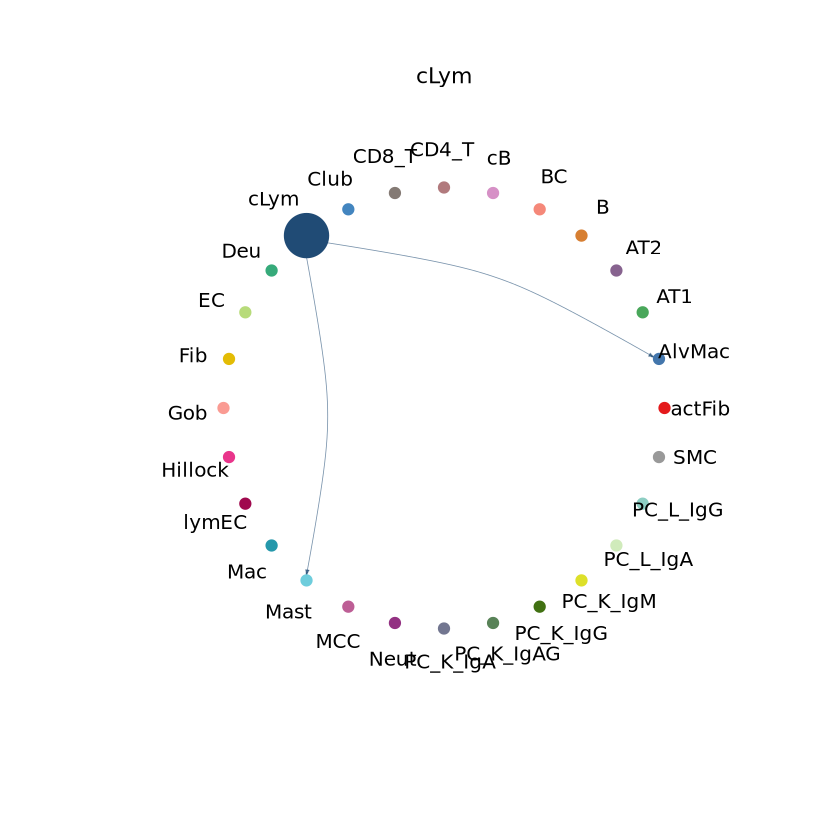

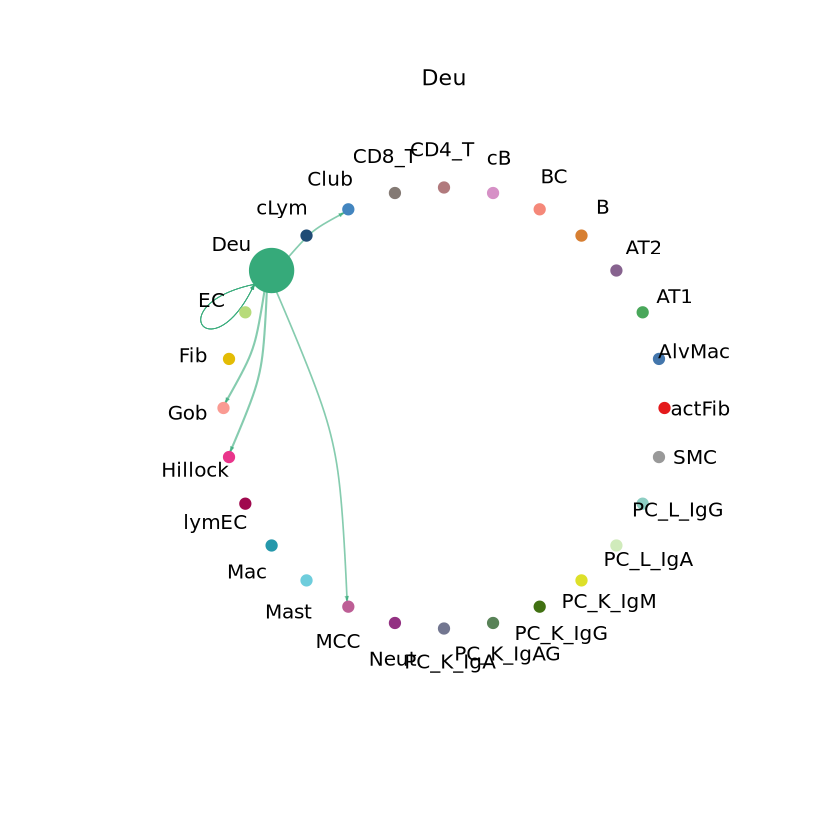

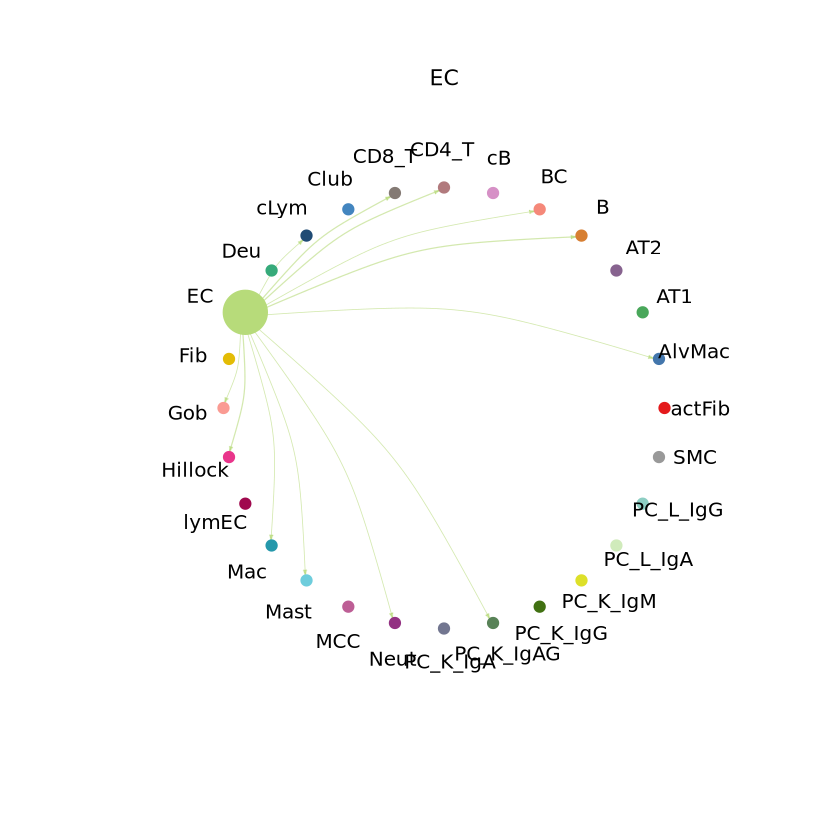

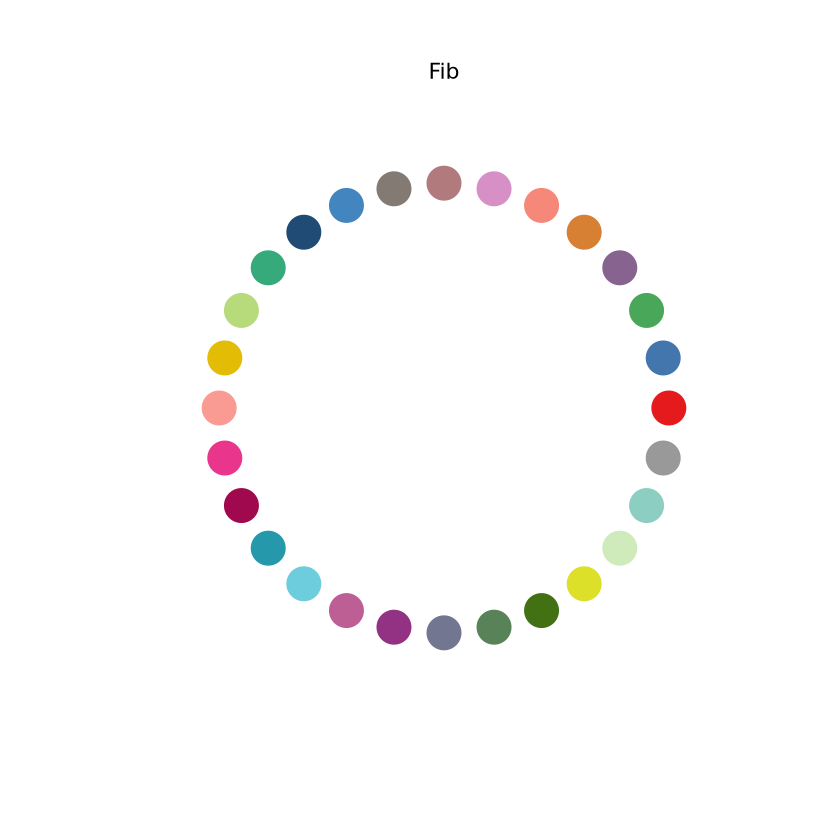

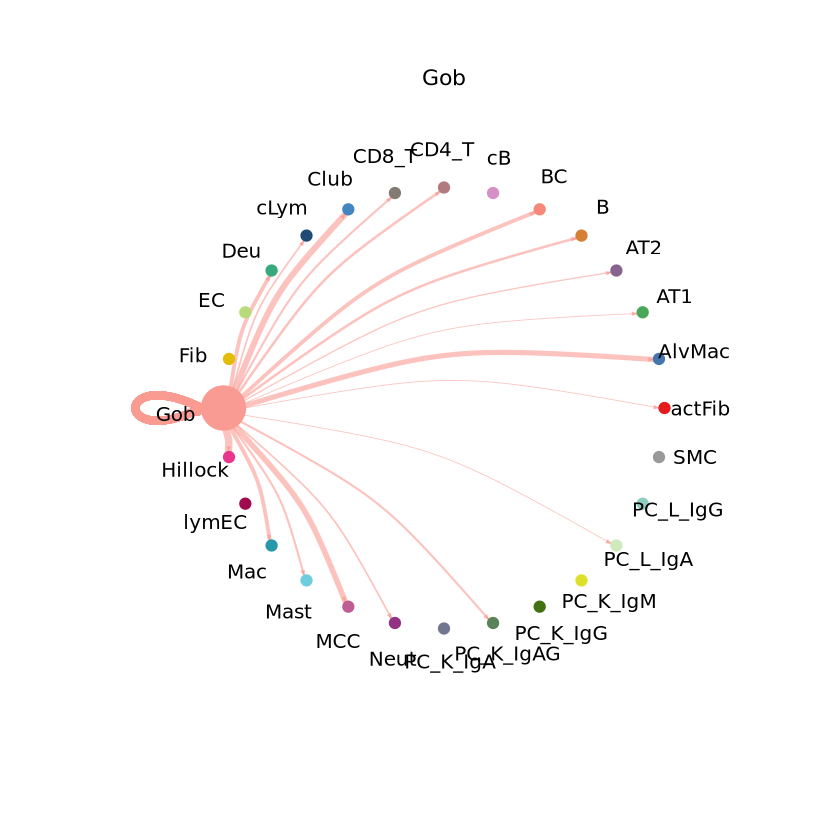

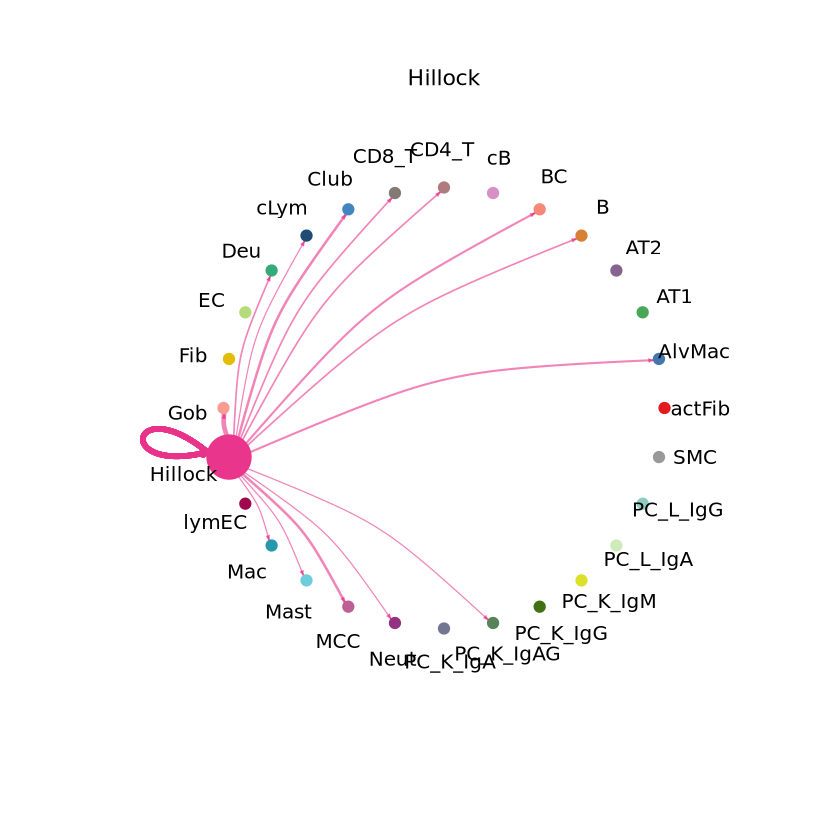

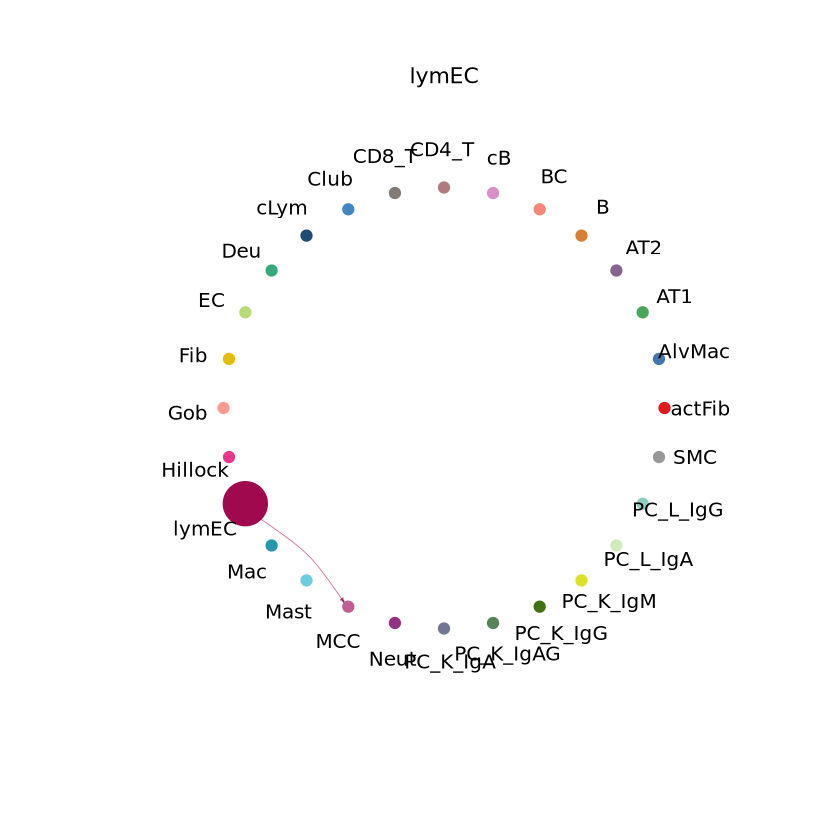

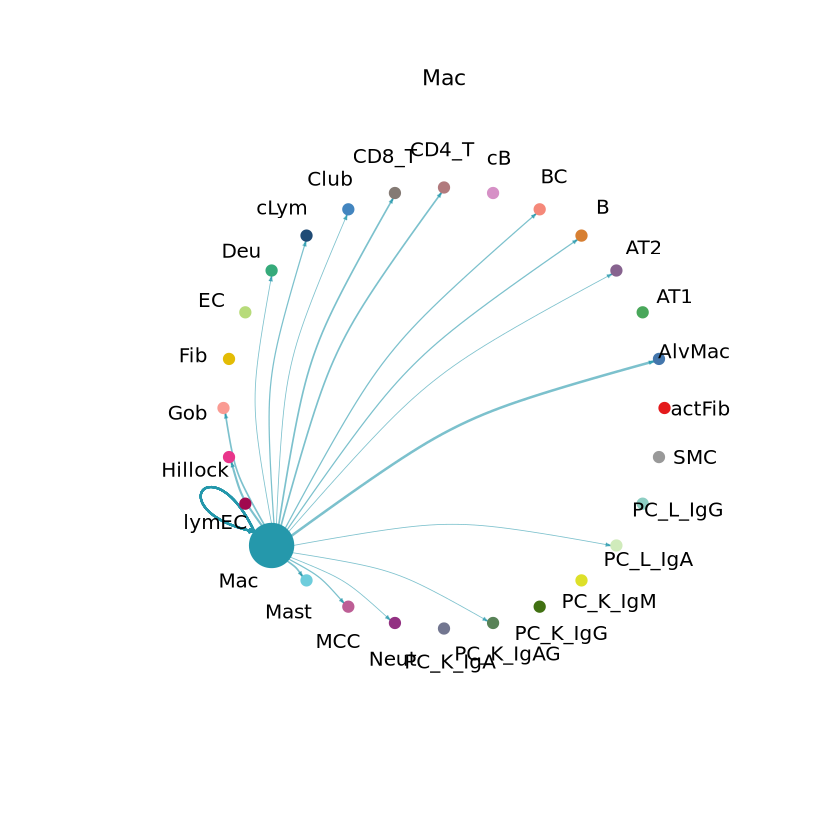

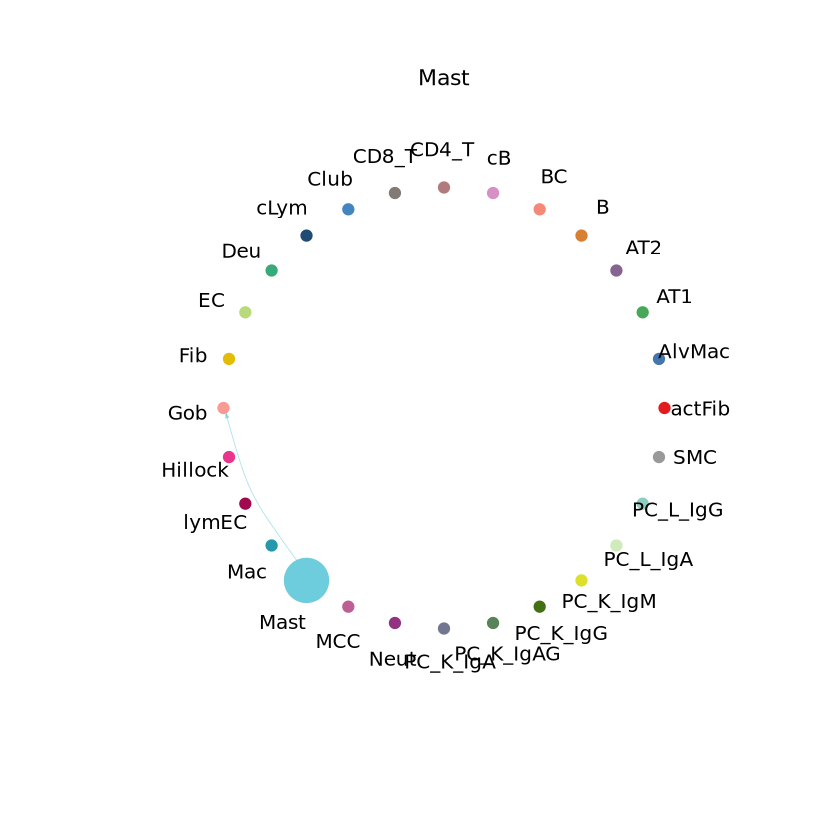

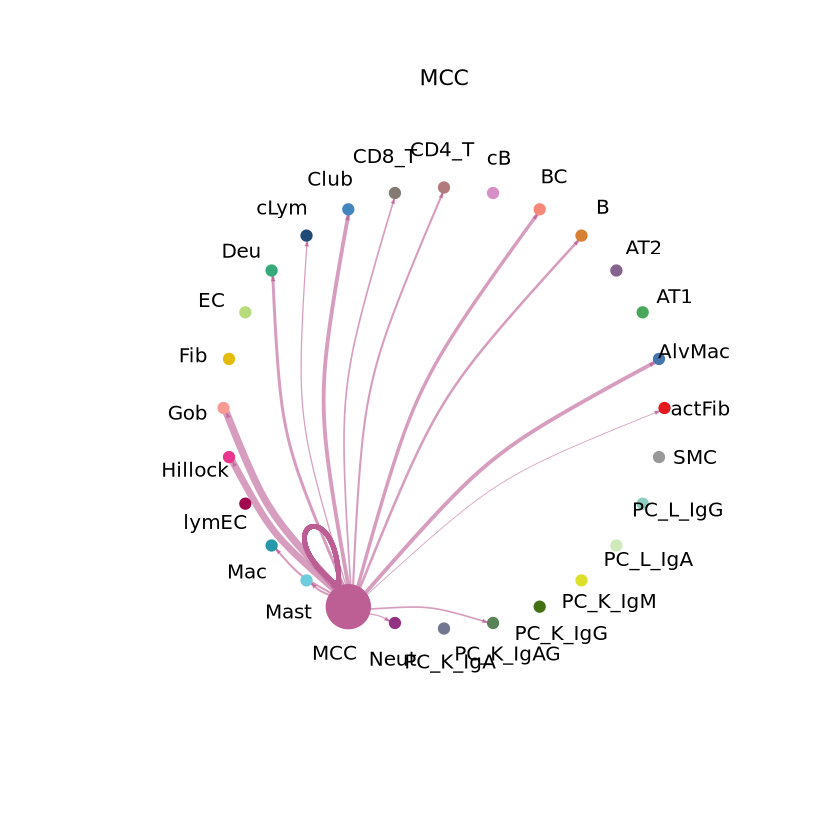

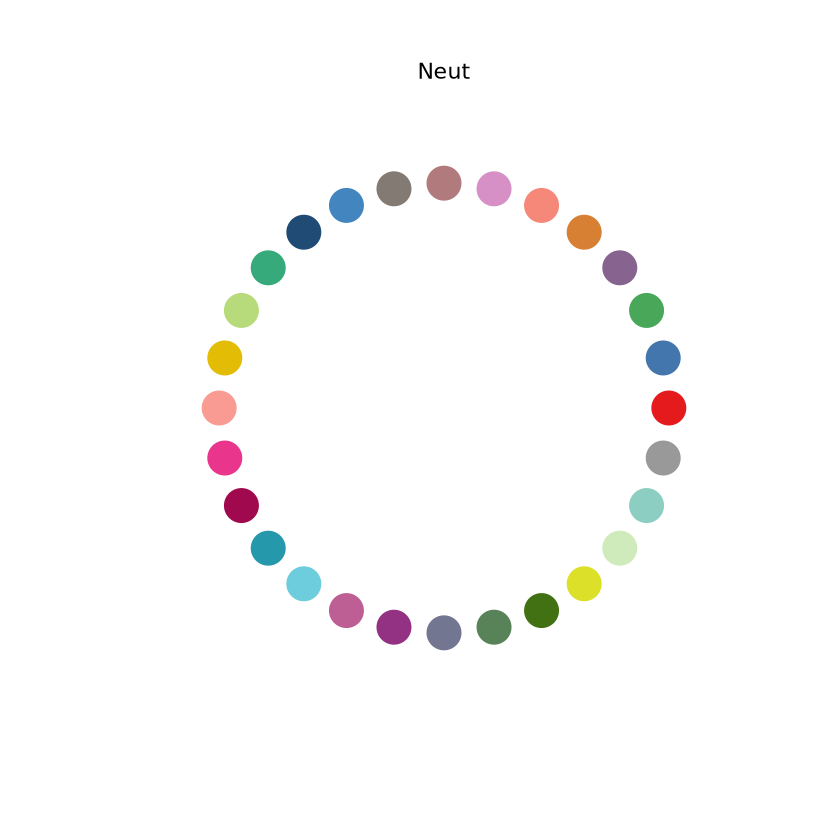

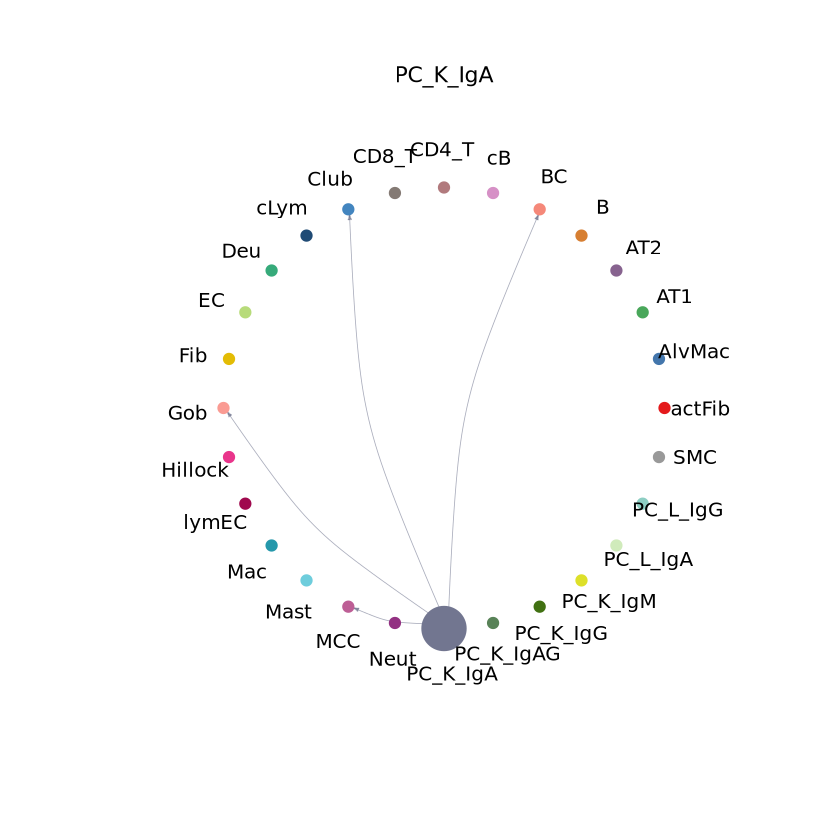

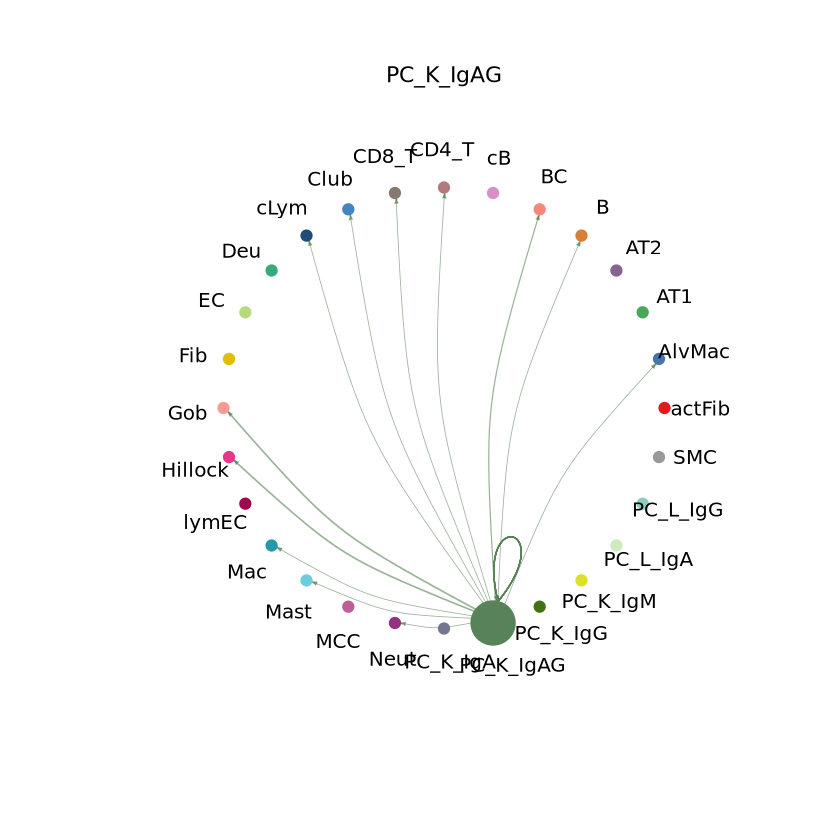

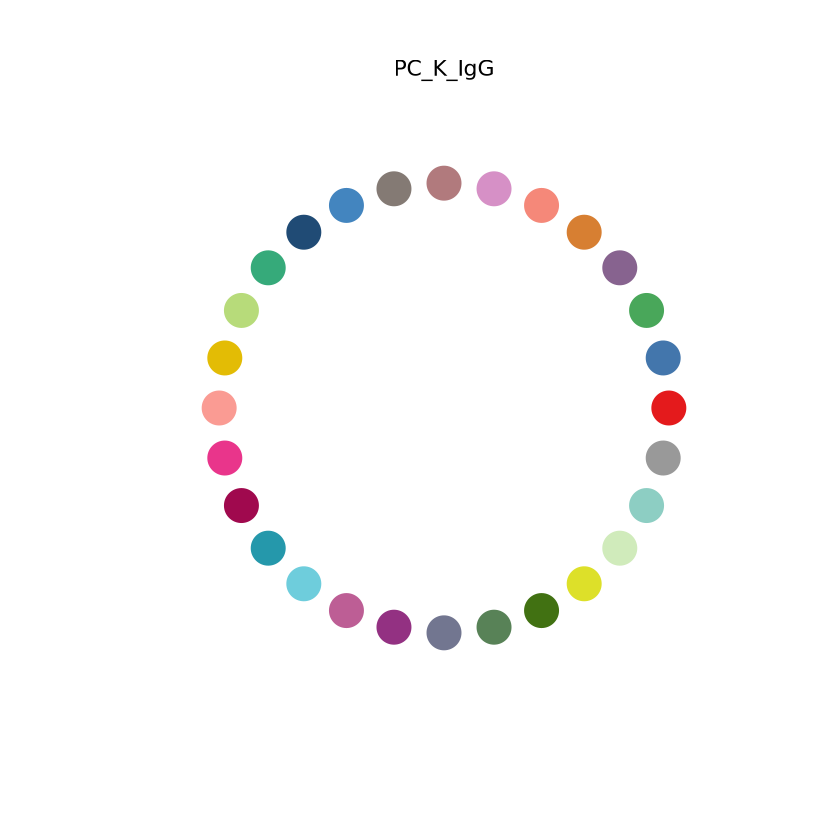

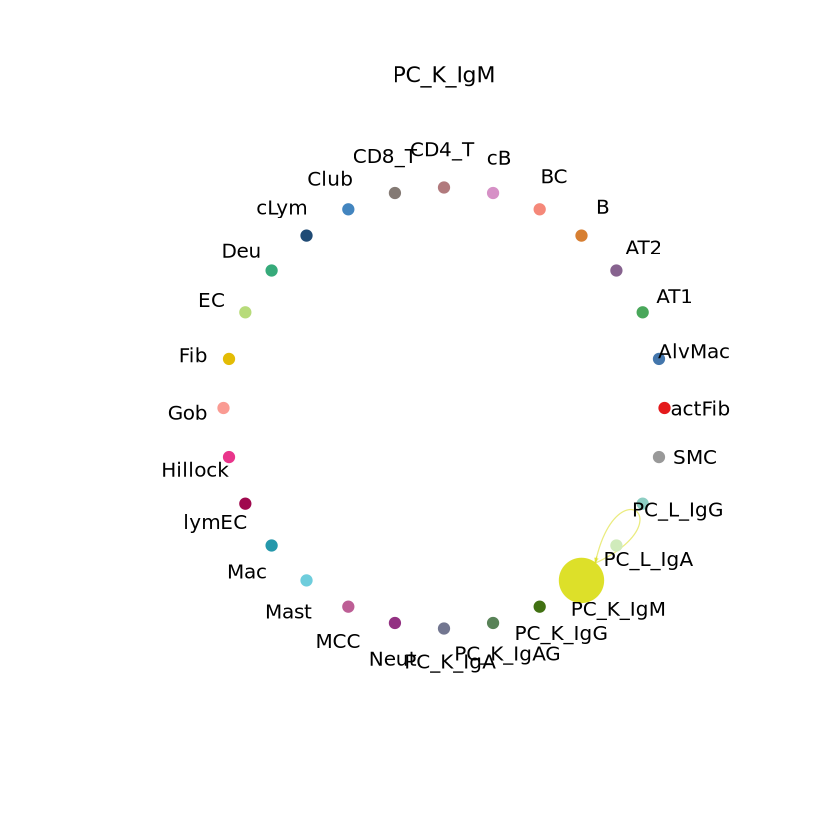

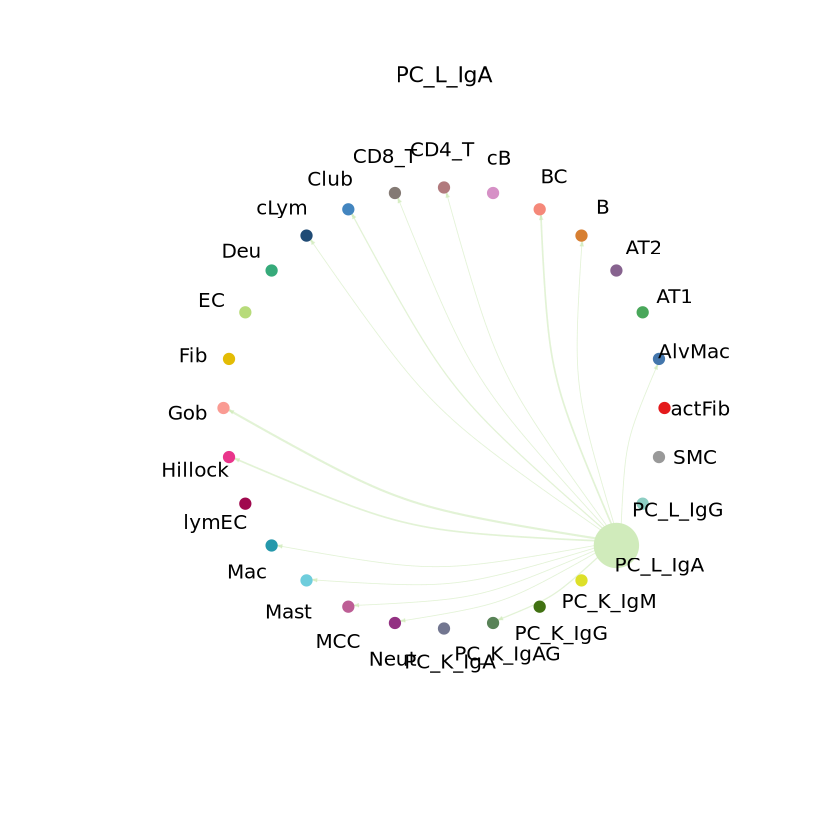

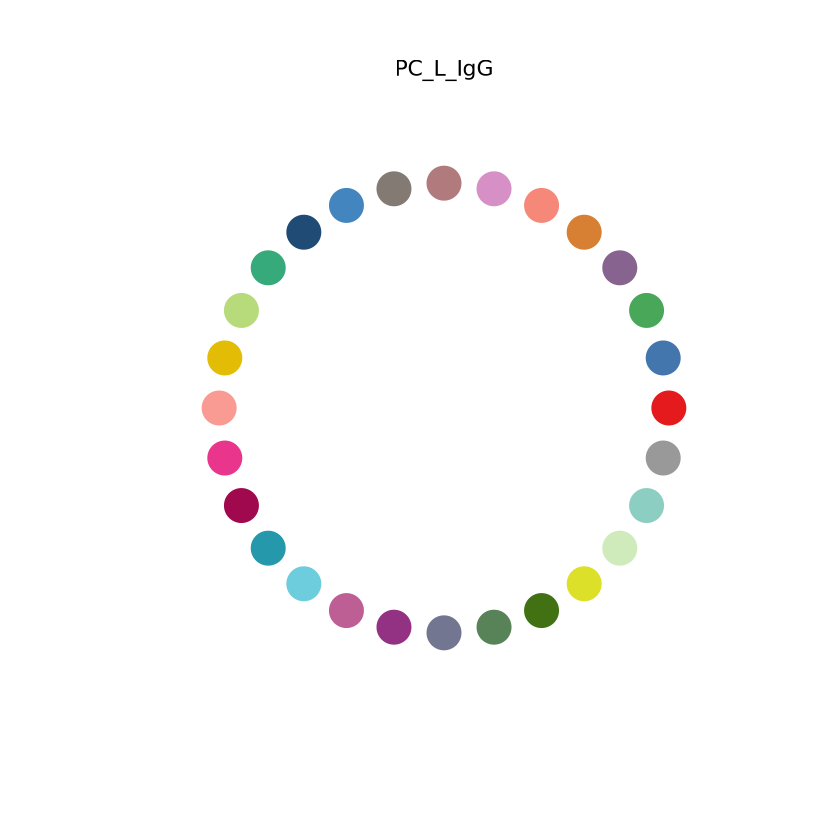

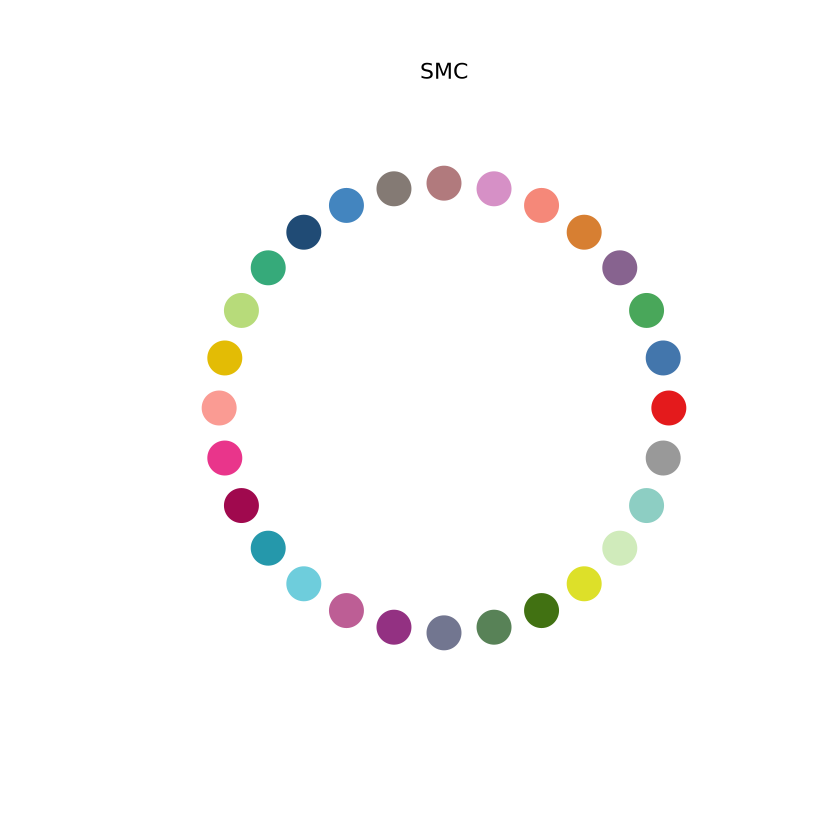

In [16]:
# Due to the complicated cell-cell communication network, 
# we can examine the signaling sent from each cell group. 
# Here we also control the parameter edge.weight.max so that 
# we can compare edge weights between differet networks.

mat <- cellchat@net$count

for (i in 1:nrow(mat)) {

  # Create a new matrix with the same dimensions as the original, but with all values set to zero
  mat2 <- matrix(0, nrow = nrow(mat), ncol = ncol(mat), dimnames = dimnames(mat))
  # Copy the i-th row of the original matrix into the new matrix
  mat2[i, ] <- mat[i, ]
  # Visualize the new matrix using netVisual_circle

  par(mfrow = c(1,1), xpd=TRUE)

  netVisual_circle(
    mat2, 
    vertex.weight = rowSums(mat2), # rowSums(mat) or groupSize, both should work
    weight.scale = T, 
    edge.weight.max = max(mat), 
    title.name = rownames(mat)[i]
  )
  
}

In [ ]:



# We now need to check the ligand recetor interactions table to select 
# interactioons that seems interesign to us
# or maybe one group of cells in general

# define the idents indexes
idents <- levels(cellchat@idents)
idx_idents <- seq_along(idents)
names(idx_idents) <- idents
print(idx_idents)
# we are interested mainly in basal cells 
groups_names <- c("basal")
# get the index of the basal cells
idx_groups <- idx_idents[groups_names]
print(idx_groups)

# Extracting interaction tables ------------------------------------------------
interactions <- subsetCommunication(
  cellchat,
  thresh = 0.05
) # jus tget the complete table then subset as needed.

# in this case we are interested in basal cells
# so we will select interactions where basal cells are either the source or the target
basal_interactions <- interactions %>%
  filter(source %in% "basal" | target %in% "basal")

# extract the pathway names
pathways.show <- unique(basal_interactions$pathway_name)
print(pathways.show)

for (pathway in pathways.show) {
 # Circle plot
  par(mfrow=c(1,1), xpd = TRUE) # `xpd = TRUE` should be added to show the title
  netVisual_aggregate(cellchat, signaling = pathway, layout = "circle")
}

# Visualize the computed centrality scores using heatmap, allowing ready identification of major signaling roles of cell groups
for (pathway in pathways.show) {
  # Circle plot
  par(mfrow=c(1,1), xpd = TRUE) # `xpd = TRUE` should be added to show the title
  netAnalysis_signalingRole_network(
    cellchat, 
    signaling = pathway, 
    width = 8, 
    height = 2.5, 
    font.size = 10
  )

}

# Due to the complicated cell-cell communication network, 
# we can examine the signaling sent from each cell group. 
# Here we also control the parameter edge.weight.max so that 
# we can compare edge weights between differet networks.

mat <- cellchat@net$count

for (i in 1:nrow(mat)) {

  # Create a new matrix with the same dimensions as the original, but with all values set to zero
  mat2 <- matrix(0, nrow = nrow(mat), ncol = ncol(mat), dimnames = dimnames(mat))
  # Copy the i-th row of the original matrix into the new matrix
  mat2[i, ] <- mat[i, ]
  # Visualize the new matrix using netVisual_circle

  par(mfrow = c(1,1), xpd=TRUE)

  netVisual_circle(
    mat2, 
    vertex.weight = rowSums(mat2), # rowSums(mat) or groupSize, both should work
    weight.scale = T, 
    edge.weight.max = max(mat), 
    title.name = rownames(mat)[i]
  )
  
}

# NOTE: 
# It may help plotting both suign rowSums(mat) and groupSize 
# While rowSums(mat) will give us the total number of interactions sent from each cell group,
# groupSize will give us the number of cells in each group, which can help us 
# understand whether the number of interactions is simply due to having more cells 
# in that group or if it's due to higher interaction activity per cell. 



# so we will select interactions where basal cells are either the source or the target
secretory_ciliated_interactions <- interactions[
  interactions$source == "secretory-ciliated" & interactions$target == "secretory-ciliated",
]

# extract the pathway names
pathways.show <- unique(secretory_ciliated_interactions$pathway_name)
print(pathways.show)


pathways.show <- c("CEACAM")
vertex.receiver = seq(1,4) # a numeric vector. 
netVisual_aggregate(cellchat, signaling = pathways.show,  vertex.receiver = vertex.receiver)

pathways.show <- c("CEACAM")
par(mfrow=c(1,1))
netVisual_aggregate(
  cellchat, 
  signaling = pathways.show, 
  vertex.receiver = vertex.receiver,
  layout = "hierarchy"
)

# NOTE: I dont like hihrarchy plots, the y are overc omplicated and dont look as good, 
# probably best to use circel pltos or chord diagrams for this.
# vertex.receiver is only used for hierarchy plot, so would probably not include it in the pipeline

# NOTE: when wanting to visulaise signalling pathways
# - circle plot or chord diagram or heatmap or heatamap 

# heatmap 
pathways.show <- unique(interactions$pathway_name)

for (pathway in pathways.show) {
  
  par(mfrow=c(1,1))
  print(netVisual_heatmap(cellchat, signaling = pathway, color.heatmap = "Reds"))

}


# could acompany the pathway with where in the distribution of porbabilities
# for all pathways is happening. Like:

library(ggplot2)

val <- 8.82e-05

ggplot(interactions, aes(x = prob)) +
  geom_density() +
  geom_vline(xintercept = val, color = "red", linetype = "dashed", linewidth = 1) +
  scale_x_log10() +
  theme_classic() +
  labs(
    title = "Distribution of CellChat interaction probabilities",
    x = "Interaction probability (log10 scale)",
    y = "Density"
  )

# altohuh  this probaility would have to be per pair of cell types,
# this would ahve to be per record in the interactions table 

# We can also also check the LR pair contribution towards each apthway 

for (pathway in pathways.show) {
  
  par(mfrow=c(1,1))
  print(netAnalysis_contribution(cellchat, signaling = pathway))
  
}

# we can even do the plots for each LR pair, 
# but this is probably not something we would want to do in the pipeline,
# as it would be too many plots, but could be something we do for a few selected LR pairs.


# This could be done for each cell type as source, could be achievable to include in teh pipeline

# (1) show all the significant interactions (L-R pairs) from some cell groups (defined by 'sources.use') to other cell groups (defined by 'targets.use')
netVisual_bubble(
  cellchat, 
  sources.use = 6, # just loop over the sources
  #targets.use = c(5:11), 
  remove.isolate = FALSE
)
#> Comparing communications on a single object


for (i in 1:nrow(mat)) {
  
  par(mfrow = c(1,1), xpd=TRUE)
  
  print(
    netVisual_bubble(
      cellchat, 
      sources.use = i, # just loop over the sources
      #targets.use = c(5:11), 
      remove.isolate = FALSE,
      title.name = rownames(mat)[i]
    )
  )
  
}

# basically the same thing but now its a chord diagram 

# show all the significant interactions (L-R pairs) from some cell groups (defined by 'sources.use') to other cell groups (defined by 'targets.use')
# show all the interactions sending from Inflam.FIB
netVisual_chord_gene(
  cellchat, 
  sources.use = 4, 
  targets.use = c(5:11), 
  lab.cex = 0.5,
  legend.pos.y = 30
)

for (i in 1:nrow(mat)) {
  
  par(mfrow = c(1,1), xpd=TRUE)
  
  print(
    netVisual_chord_gene(
      cellchat, 
      sources.use = i, 
      #targets.use = c(5:11), 
      lab.cex = 0.5,
      legend.pos.y = 30,
      title.name = rownames(mat)[i]
    )
  )
  
}



# violin plots 

plotGeneExpression(cellchat, signaling = "CXCL", enriched.only = TRUE, type = "violin")

for (pathway in pathways.show) {
  
  par(mfrow=c(1,1))
  print(
    plotGeneExpression(
      cellchat, 
      signaling = pathway, 
      enriched.only = TRUE, 
      type = "violin"
    )
  )
  
}

# most violin plots will look bad, due to the fact that most pathways will only have a few LR pairs, 
# and most of the LR pairs will not be significant, so the violin plots will be mostly empty.
# also this is a subset of subse, so very few expression values/counts


#### idntify signalling roles

# TODO: Need to add this to the create-cellchat_objs script

# Compute the network centrality scores
cellchat <- netAnalysis_computeCentrality(cellchat, slot.name = "netP") # the slot 'netP' means the inferred intercellular communication network of signaling pathways



# Visualize the computed centrality scores using heatmap, allowing ready identification of major signaling roles of cell groups
netAnalysis_signalingRole_network(cellchat, signaling = pathways.show, width = 8, height = 2.5, font.size = 10)


for (pathway in pathways.show) {
  
  par(mfrow=c(1,1))
  print(
    netAnalysis_signalingRole_network(
      cellchat, 
      signaling = pathway, 
      width = 8, 
      height = 2.5, 
      font.size = 10
    )
  )
  
}


## visulise dominant senders/sources and receivers.targets in a 2d space

# Signaling role analysis on the aggregated cell-cell communication network from all signaling pathways
gg1 <- netAnalysis_signalingRole_scatter(cellchat)
#> Signaling role analysis on the aggregated cell-cell communication network from all signaling pathways
# Signaling role analysis on the cell-cell communication networks of interest
gg2 <- netAnalysis_signalingRole_scatter(
  cellchat, 
  signaling = pathways.show,
)
#> Signaling role analysis on the cell-cell communication network from user's input
gg1 + gg2

# now in a loop 
for (pathway in pathways.show) {
  
  par(mfrow=c(1,1))
  print(
    netAnalysis_signalingRole_scatter(
      cellchat, 
      signaling = pathway
    )
  )
  
}

# i think its a bug, the counts when usign singallign is always 0 
# also i dont knwo what count i refering to

###### (C) Identify signals contributing the most to outgoing or incoming signaling of certain cell groups

# Signaling role analysis on the aggregated cell-cell communication network from all signaling pathways
ht1 <- netAnalysis_signalingRole_heatmap(cellchat, pattern = "outgoing")
ht2 <- netAnalysis_signalingRole_heatmap(cellchat, pattern = "incoming")
ht1 + ht2

# NOTE:
#  The top colored bar plot shows the total signaling strength of a cell group 
# by summarizing all signaling pathways displayed in the heatmap. 
# The right grey bar plot shows the total signaling strength of 
# a signaling pathway by summarizing all cell groups displayed in the heatmap.


# Signaling role analysis on the cell-cell communication networks of interest
ht <- netAnalysis_signalingRole_heatmap(cellchat, signaling = pathways.show)
print(ht)
# lets say if we want to do it for each pathway(oor a few related pathways), we can do it in a loop
# I think the big heatmap would suffice

##### Identify global communication patterns to explore how multiple cell types and signaling pathways coordinate together

# TODO: I need to continue here !!!

### outgoing signaling patterns of signaling pathways
library(NMF)
library(ggalluvial)

selectK(cellchat, pattern = "outgoing") # 6 

nPatterns = 6
cellchat <- identifyCommunicationPatterns(cellchat, pattern = "outgoing", k = nPatterns)

# river plot
netAnalysis_river(cellchat, pattern = "outgoing")

# dot plot
netAnalysis_dot(cellchat, pattern = "outgoing")

### incoming signaling patterns of signaling pathways

selectK(cellchat, pattern = "incoming") # 4
nPatterns = 4

cellchat <- identifyCommunicationPatterns(cellchat, pattern = "incoming", k = nPatterns)

# river plot
netAnalysis_river(cellchat, pattern = "incoming")

# dot plot
netAnalysis_dot(cellchat, pattern = "incoming")


##### Manifold and classification learning analysis of signaling networks

## Identify signaling groups based on their functional similarity

cellchat <- computeNetSimilarity(cellchat, type = "functional")
cellchat <- netEmbedding(cellchat, type = "functional")
#> Manifold learning of the signaling networks for a single dataset
cellchat <- netClustering(cellchat, type = "functional")
#> Classification learning of the signaling networks for a single dataset
# Visualization in 2D-space
netVisual_embedding(cellchat, type = "functional", label.size = 3.5)

netVisual_embeddingZoomIn(cellchat, type = "functional", nCol = 2) # not very useful


#### Identify signaling groups based on structure similarity

cellchat <- computeNetSimilarity(cellchat, type = "structural")
cellchat <- netEmbedding(cellchat, type = "structural")
#> Manifold learning of the signaling networks for a single dataset
cellchat <- netClustering(cellchat, type = "structural")
#> Classification learning of the signaling networks for a single dataset
# Visualization in 2D-space
netVisual_embedding(cellchat, type = "structural", label.size = 3.5)


netVisual_embeddingZoomIn(cellchat, type = "structural", nCol = 2) # not very useful 


